<a href="https://colab.research.google.com/github/Mat9408/Atividades_CursoAnalistaDeDados_EBAC/blob/main/M%C3%B3dulo_27_Tarefa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Correlação entre consumo de energia elétrica e temperatura

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

##Energia

In [2]:
!wget -q 'https://raw.githubusercontent.com/andre-marcos-perez/ebac-course-utils/main/dataset/energia.csv' -O 'energia.csv'

In [3]:
energia= pd.read_csv('energia.csv', sep=';', parse_dates=[0], infer_datetime_format=True)

/tmp/ipykernel_715/3625688149.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  energia= pd.read_csv('energia.csv', sep=';', parse_dates=[0], infer_datetime_format=True)


In [4]:
energia.head(200)

,referencia,residencial,industrial,comercial
0,2004-01-01,3694386,6977471,2450453
1,2004-02-01,3511541,7084623,2396965
2,2004-03-01,3629455,7087613,2402521
3,2004-04-01,3733863,7384540,2580914
4,2004-05-01,3537269,7258307,2344084
...,...,...,...,...
195,2020-04-01,5678228,6503650,3318789
196,2020-05-01,5426561,6357406,2982078
197,2020-06-01,5400703,6477439,2860468
198,2020-07-01,5496332,7279626,3015118


In [5]:
energia.tail()

,referencia,residencial,industrial,comercial
199,2020-08-01,5671487,7697947,3198269
200,2020-09-01,5756787,7723167,3431649
201,2020-10-01,6241392,8042503,3890202
202,2020-11-01,5999235,7878699,3718647
203,2020-12-01,6377972,7832769,3965809


In [6]:
energia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   referencia   204 non-null    datetime64[ns]
 1   residencial  204 non-null    int64         
 2   industrial   204 non-null    int64         
 3   comercial    204 non-null    int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 6.5 KB


  - A granularidade da base de dados energia é mensal, já que os dados foram aferidos mensalmente de Janeiro de 2004 a Dezembro de 2020.
  - O intervalo de tempo mínimo é a diferença de um mês. Ex.: Janeiro de 2004 a Fevereiro de 2004. O intervalo máximo é todo o período registrado pelo DataFrame.

## Temperatura

In [7]:
!wget -q 'https://raw.githubusercontent.com/andre-marcos-perez/ebac-course-utils/main/dataset/temperatura.csv' -O 'temperatura.csv'

In [8]:
temperatura = pd.read_csv('temperatura.csv', sep=';', parse_dates=[0], infer_datetime_format=True)

/tmp/ipykernel_715/1081947969.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  temperatura = pd.read_csv('temperatura.csv', sep=';', parse_dates=[0], infer_datetime_format=True)


In [9]:
temperatura.head()

,referencia,temp-media-sp,temp-media-rj,temp-media-mg
0,2018-07-15,18,21.0,19.0
1,2018-07-16,19,23.0,19.0
2,2018-07-17,17,21.0,19.0
3,2018-07-18,18,23.0,19.0
4,2018-07-19,19,23.0,19.0


In [10]:
temperatura.tail()

,referencia,temp-media-sp,temp-media-rj,temp-media-mg
896,2020-12-27,20,24.0,23.0
897,2020-12-28,21,25.0,23.0
898,2020-12-29,22,27.0,23.0
899,2020-12-30,24,27.0,23.0
900,2020-12-31,23,29.0,24.0


  - A granularidade da base de dados é diária na qual se inicia no dia 15 de Julho de 2018 e se encerra no dia 31 de Dezembro de 2020.
  - O intervalo mínimo de tempo desta base de dados é de um dia. Ex: Do dia 15/07/2018 até o dia 16/07/2018. Já o intervalo máximo de tempo é todo o período registrado no DataFrame.

## Processamento - DataFrame Energia

  - Atribuindo ao index a coluna temporal

In [11]:
energia = energia.set_index(keys=['referencia'])

In [12]:
energia.head()

,residencial,industrial,comercial
referencia,,,
2004-01-01,3694386,6977471,2450453
2004-02-01,3511541,7084623,2396965
2004-03-01,3629455,7087613,2402521
2004-04-01,3733863,7384540,2580914
2004-05-01,3537269,7258307,2344084


  - Selecionar os dados entre 2019 e 2020.

In [13]:
energia['2019-01-01':'2020-12-01'].head(24)

,residencial,industrial,comercial
referencia,,,
2019-01-01,6389714,7545071,4370412
2019-02-01,6188834,7285407,4365504
2019-03-01,6072327,7556147,4303463
2019-04-01,5610278,7494816,4115920
2019-05-01,5785412,7597072,4141319
2019-06-01,5269701,7384031,3726296
2019-07-01,5152318,7434149,3547092
2019-08-01,5201820,7485988,3575392
2019-09-01,5376428,7411807,3768173


## Processamento - DataFrame Temperatura

  - Atribuindo ao index a coluna temporal

In [14]:
temperatura = temperatura.set_index(keys=['referencia'])

In [15]:
temperatura.head()

,temp-media-sp,temp-media-rj,temp-media-mg
referencia,,,
2018-07-15,18,21.0,19.0
2018-07-16,19,23.0,19.0
2018-07-17,17,21.0,19.0
2018-07-18,18,23.0,19.0
2018-07-19,19,23.0,19.0


  - Selecionando os dados entre 2019 e 2020

In [16]:
temperatura['2019-01-01':'2020-12-31'].head(731)

,temp-media-sp,temp-media-rj,temp-media-mg
referencia,,,
2019-01-01,22,28.0,21.0
2019-01-02,25,28.0,24.0
2019-01-03,26,31.0,24.0
2019-01-04,23,31.0,22.0
2019-01-05,21,28.0,23.0
...,...,...,...
2020-12-27,20,24.0,23.0
2020-12-28,21,25.0,23.0
2020-12-29,22,27.0,23.0


  - Removendo todas as linhas que apresentam valor NaN

In [17]:
temperatura = temperatura.dropna()

In [18]:
temperatura.head(813)

,temp-media-sp,temp-media-rj,temp-media-mg
referencia,,,
2018-07-15,18,21.0,19.0
2018-07-16,19,23.0,19.0
2018-07-17,17,21.0,19.0
2018-07-18,18,23.0,19.0
2018-07-19,19,23.0,19.0
...,...,...,...
2020-12-27,20,24.0,23.0
2020-12-28,21,25.0,23.0
2020-12-29,22,27.0,23.0


  - Tirando a média das temperaturas

In [19]:
temperatura['temp-media'] = temperatura.mean(axis=1)

In [20]:
temperatura.head()

,temp-media-sp,temp-media-rj,temp-media-mg,temp-media
referencia,,,,
2018-07-15,18,21.0,19.0,19.333333
2018-07-16,19,23.0,19.0,20.333333
2018-07-17,17,21.0,19.0,19.000000
2018-07-18,18,23.0,19.0,20.000000
2018-07-19,19,23.0,19.0,20.333333


  - Reamostrando a granularidade com o Resampling

In [21]:
resampled = temperatura.resample(rule='1m').mean()

/tmp/ipykernel_715/1345221001.py:1: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'ME' instead.
  resampled = temperatura.resample(rule='1m').mean()


In [22]:
resampled['2019-01-01':'2020-12-31'].head(24)

,temp-media-sp,temp-media-rj,temp-media-mg,temp-media
referencia,,,,
2019-01-31,24.000000,29.774194,24.483871,26.086022
2019-02-28,21.928571,27.464286,23.571429,24.321429
2019-03-31,21.258065,26.645161,23.032258,23.645161
2019-04-30,20.833333,26.066667,22.600000,23.166667
2019-05-31,19.161290,24.193548,21.225806,21.526882
2019-06-30,17.600000,22.800000,19.333333,19.911111
2019-07-31,15.580645,21.096774,18.193548,18.290323
2019-08-31,16.032258,20.935484,20.129032,19.032258
2019-09-30,18.333333,22.766667,23.100000,21.400000


## Correlação

### Consumo residencial

/tmp/ipykernel_715/4025739943.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  grafico = sns.lineplot(data= resampled['2019-01-01':'2020-12-31'], x='referencia', y='temp-media', marker='1', palette='pastel')


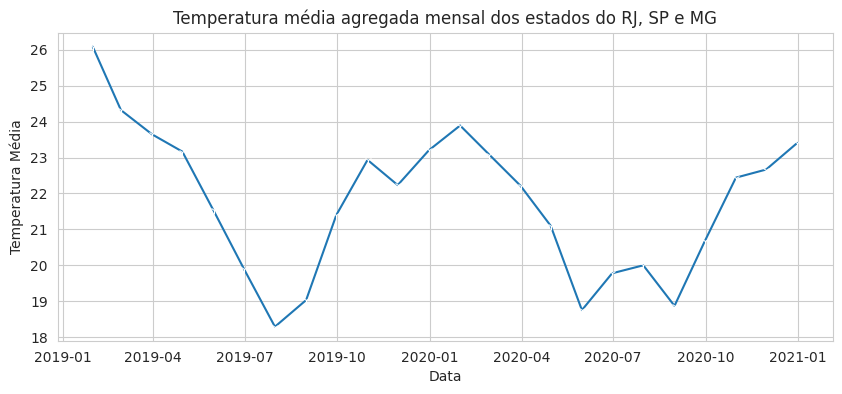

In [23]:
with sns.axes_style('whitegrid'):
  grafico = sns.lineplot(data= resampled['2019-01-01':'2020-12-31'], x='referencia', y='temp-media', marker='1', palette='pastel')
  grafico.set(title='Temperatura média agregada mensal dos estados do RJ, SP e MG', ylabel='Temperatura Média', xlabel='Data');
  grafico.figure.set_size_inches(10, 4)

/tmp/ipykernel_715/995790883.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  grafico = sns.lineplot(data= energia['2019-01-01':'2020-12-31'], x='referencia', y='residencial', marker='1', palette='pastel', color='red')


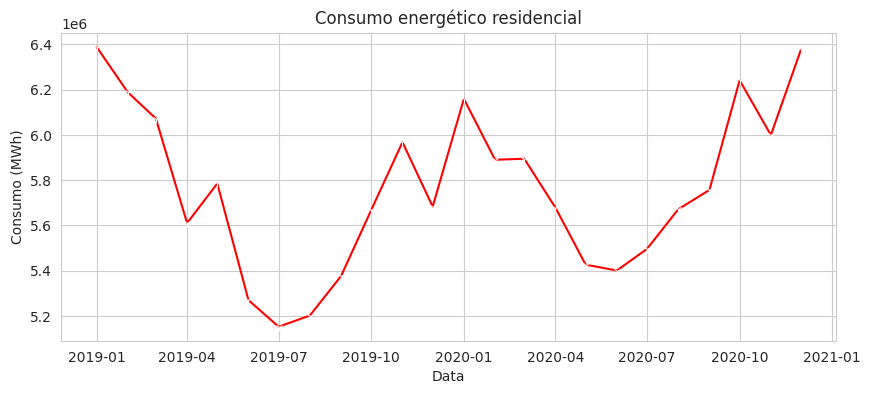

In [24]:
with sns.axes_style('whitegrid'):
  grafico = sns.lineplot(data= energia['2019-01-01':'2020-12-31'], x='referencia', y='residencial', marker='1', palette='pastel', color='red')
  grafico.set(title='Consumo energético residencial', ylabel='Consumo (MWh)', xlabel='Data');
  grafico.figure.set_size_inches(10, 4)

In [26]:
np.corrcoef(energia['residencial']['2018-07-01':'2020-12-01'], resampled['temp-media']['2018-07-01':'2020-12-31'])

array([[1.       , 0.8173488],
       [0.8173488, 1.       ]])

A temperatura é sim um bom parâmetro para prever o consumo de energia pois, conforme a temperatura média aumenta, o consumo de energia elétrica também é ampliado nas residências. Analisando os gráficos gerados podemos ver semelhanças nas tendências de verão e inverno. Possivelmente isso se deve pela frequente utilização de ventiladores, ar-condicionados e maior consumo de geladeiras.

### Consumo comercial

/tmp/ipykernel_715/2119480248.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  grafico = sns.lineplot(data= energia['2019-01-01':'2020-12-31'], x='referencia', y='comercial', marker='1', palette='pastel', color='orange')


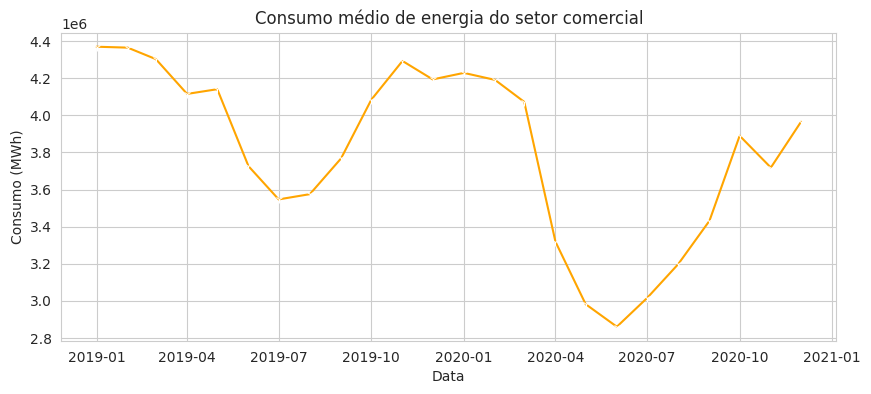

In [27]:
with sns.axes_style('whitegrid'):
  grafico = sns.lineplot(data= energia['2019-01-01':'2020-12-31'], x='referencia', y='comercial', marker='1', palette='pastel', color='orange')
  grafico.set(title='Consumo médio de energia do setor comercial', ylabel='Consumo (MWh)', xlabel='Data');
  grafico.figure.set_size_inches(10, 4)

In [29]:
np.corrcoef(energia['comercial']['2018-07-01':'2020-12-01'], resampled['temp-media']['2018-07-01':'2020-12-31'])

array([[1.        , 0.81413452],
       [0.81413452, 1.        ]])

A temperatura é um bom atributo de avaliação. Os padrões são semelhantes ao consumo residencial, porém, o que diferencia a utilização de energia no setor comercial é sua maior utilização em relação as residências. O que difere um pouco do padrão apresentado é a queda no primeiro semestre de 2020 quando tivemos a pandemia do COVID-19 e ocorreu o lockdown.

### Consumo Industrial

/tmp/ipykernel_715/2648551299.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  grafico = sns.lineplot(data=energia['2019-01-01':'2020-12-31'], x='referencia', y='industrial', marker='1', palette='pastel', color='green')


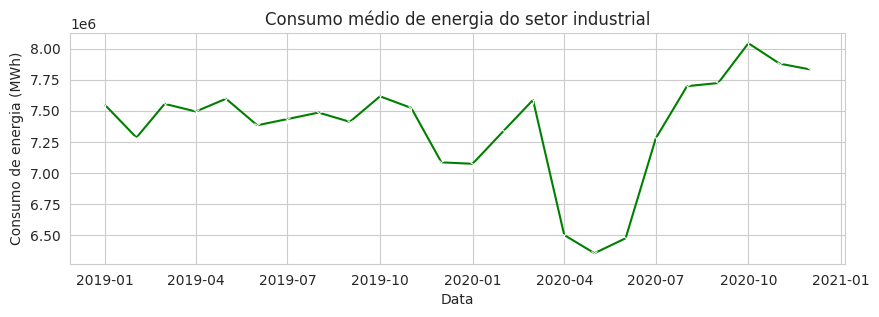

In [30]:
with sns.axes_style('whitegrid'):
  grafico = sns.lineplot(data=energia['2019-01-01':'2020-12-31'], x='referencia', y='industrial', marker='1', palette='pastel', color='green')
  grafico.set(title='Consumo médio de energia do setor industrial', ylabel='Consumo de energia (MWh)', xlabel='Data');
  grafico.figure.set_size_inches(10, 3)

In [32]:
np.corrcoef(energia['industrial']['2018-07-01':'2020-12-01'], resampled['temp-media']['2018-07-01':'2020-12-31'])

array([[1.        , 0.13346039],
       [0.13346039, 1.        ]])

Com relação ao consumo energéico no setor industrial, a média de temperatura não é a ideal para a previsão de consumo. Isso se dá pelo fato de que a ingestão é bem linear durante todo o ano. O ponto fora da curva é a primeira metade do ano de 2020 devido a pandemia do COVID-19 e a redução de produção do setor.